# File 3 - CodeBERT Embedding

Uses tuned CodeBERT config from File 2 to run all embedding experiments
and compare against feature-only baselines.


 Hyperparameters (from File 2)
- best_max_len = 256
- best_pooling = "cls"
- Val Macro-F1 on 5000 samples = 0.5403



## 0. Install Dependencies

In [ ]:
!pip install -q transformers datasets accelerate xgboost imbalanced-learn

## 1. Imports & Setup

In [ ]:
import ast, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.pipeline           import Pipeline
from sklearn.preprocessing      import StandardScaler
from sklearn.model_selection    import train_test_split
from sklearn.metrics            import f1_score, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling     import SMOTE, RandomOverSampler
from xgboost                    import XGBClassifier

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")

FIGS  = "/content/figures";  os.makedirs(FIGS,  exist_ok=True)
RSLTS = "/content/results";  os.makedirs(RSLTS, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

PALETTE = ["#2E4057", "#048A81", "#54C6EB", "#EF946C", "#C4A35A", "#A23B72"]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False})


Device: cuda


## 2. Configuration

In [ ]:
#Trial vs Full run
TRIAL_RUN = False          # set True for trail run
SAMPLES   = 2000 if TRIAL_RUN else None

if TRIAL_RUN:
    print("*** TRIAL RUN — 2000 rows only ***")
    print("Set TRIAL_RUN = False for the full run.")
else:
    print("FULL RUN — loading entire dataset")

#Data
HF_DATASET = "HuggingFaceTB/python-edu-annotations"

# CodeBERT best config from File 2
BEST_MAX_LEN = 256
BEST_POOLING = "cls"

# load from JSON if you saved it from File 2
# with open("best_hyperparams.json") as f:
#     best = json.load(f)
# BEST_MAX_LEN = best["best_max_len"]
# BEST_POOLING = best["best_pooling"]

print(f"CodeBERT config  →  pooling={BEST_POOLING}  max_len={BEST_MAX_LEN}")

CODEBERT_MODEL = "microsoft/codebert-base"
EMBED_BATCH    = 32

#Truncation options
TRUNCATION_OPTIONS = {
    "first_10": 10,
    "first_30": 30,
    "full":     None,
}

#Google Drive cache
DRIVE_SAVE_DIR = "/content/drive/MyDrive/codebert_file3"
if TRIAL_RUN:
    DRIVE_SAVE_DIR += "_trial"
print(f"Cache dir: {DRIVE_SAVE_DIR}")


FULL RUN — loading entire dataset
CodeBERT config  →  pooling=cls  max_len=256
Cache dir: /content/drive/MyDrive/codebert_file3


## 3. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f"Cache directory ready: {DRIVE_SAVE_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cache directory ready: /content/drive/MyDrive/codebert_file3


## 4. Feature Definitions

In [ ]:
doc_features       = ["num_comments", "comment_ratio", "has_docstring"]
lexical_features   = ["num_lines", "avg_line_length", "indentation_depth", "has_input_output"]
syntactic_features = ["num_functions", "num_loops", "num_if_statements",
                      "total_ast_nodes", "has_main_block"]
all_features = doc_features + lexical_features + syntactic_features
print(f"Feature-only ({len(all_features)} features): {all_features}")


Feature-only (12 features): ['num_comments', 'comment_ratio', 'has_docstring', 'num_lines', 'avg_line_length', 'indentation_depth', 'has_input_output', 'num_functions', 'num_loops', 'num_if_statements', 'total_ast_nodes', 'has_main_block']


## 5. Load & Split Dataset (70 / 15 / 15)

In [ ]:
def extract_code_from_prompt(text):
    if "The extract:" not in text:
        return ""
    code = text.split("The extract:")[-1]
    for marker in ("After examining the extract:", "Educational score:"):
        if marker in code:
            code = code.split(marker)[0]
    return code.strip()


In [ ]:
from datasets import load_dataset

print(f"Loading '{HF_DATASET}'...")
ds = load_dataset(HF_DATASET, split="train", streaming=True)

rows = []
for i, ex in enumerate(ds):
    if SAMPLES and i >= SAMPLES:
        break
    rows.append(ex)
    if (i + 1) % 5000 == 0:
        print(f"  {i+1:,} rows loaded...", flush=True)

df = pd.DataFrame(rows)
df["code"]  = df["prompt"].apply(extract_code_from_prompt)
df          = df.dropna(subset=["score", "code"])
df["score"] = df["score"].astype(int)
df          = df[df["score"].between(1, 5) & (df["code"].str.len() >= 20)]
df          = df.reset_index(drop=True)

print(f"\nClean dataset: {df.shape}")
print(df["score"].value_counts().sort_index().rename("count").to_frame())


In [ ]:
# 70 / 15 / 15 split
df_train, df_temp = train_test_split(df,       test_size=0.30, stratify=df["score"],       random_state=42)
df_val,  df_test  = train_test_split(df_temp,  test_size=0.50, stratify=df_temp["score"],  random_state=42)

y_tr = df_train["score"].values
y_va = df_val["score"].values
y_te = df_test["score"].values

print(f"Train : {len(df_train):,}  ({len(df_train)/len(df)*100:.0f}%)")
print(f"Val   : {len(df_val):,}   ({len(df_val)/len(df)*100:.0f}%)")
print(f"Test  : {len(df_test):,}  ({len(df_test)/len(df)*100:.0f}%)")


Train : 343,644  (70%)
Val   : 73,638   (15%)
Test  : 73,639  (15%)


## 6. EDA

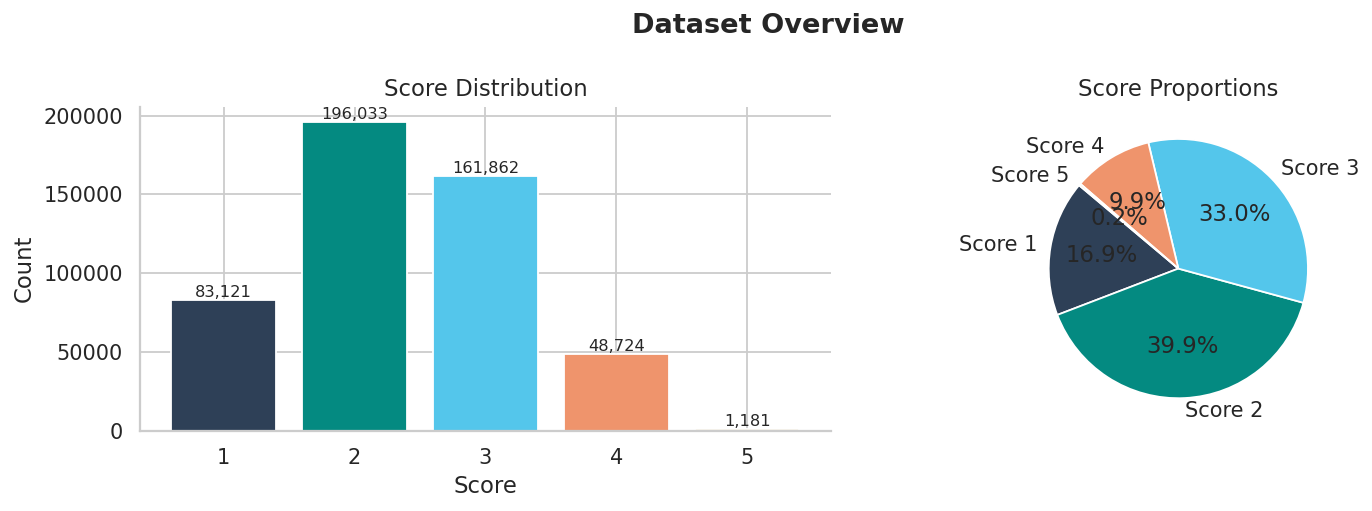

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Dataset Overview", fontweight="bold")

vc = df["score"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=PALETTE, edgecolor="white")
axes[0].set_title("Score Distribution"); axes[0].set_xlabel("Score"); axes[0].set_ylabel("Count")
for i, v in zip(vc.index, vc.values):
    axes[0].text(i-1, v + vc.max()*0.01, f"{v:,}", ha="center", fontsize=9)

axes[1].pie(vc.values, labels=[f"Score {i}" for i in vc.index],
            colors=PALETTE, autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor": "white"})
axes[1].set_title("Score Proportions")

plt.tight_layout()
plt.savefig(os.path.join(FIGS, "eda_distribution.png")); plt.show()


## 7. Feature-only Extraction

In [ ]:
def get_features(code_str):
    features = {}
    try:
        tree = ast.parse(code_str)
        features["total_ast_nodes"]   = len(list(ast.walk(tree)))
        features["num_functions"]     = sum(isinstance(n, ast.FunctionDef) for n in ast.walk(tree))
        features["num_loops"]         = sum(isinstance(n, (ast.For, ast.While)) for n in ast.walk(tree))
        features["num_if_statements"] = sum(isinstance(n, ast.If) for n in ast.walk(tree))
        features["has_docstring"]     = int(ast.get_docstring(tree) is not None)
    except SyntaxError:
        features.update({"total_ast_nodes": 0, "num_functions": 0,
                         "num_loops": 0, "num_if_statements": 0, "has_docstring": 0})
    lines = code_str.split("\n")
    n = len(lines)
    features["num_lines"]         = n
    features["num_comments"]      = sum(1 for l in lines if "#" in l)
    features["comment_ratio"] = features["num_comments"] / max(1, n)
    features["avg_line_length"]   = sum(len(l) for l in lines) / (n + 1)
    features["indentation_depth"] = (max((len(l) - len(l.lstrip())) for l in lines if l.strip())
                                     if any(l.strip() for l in lines) else 0)
    features["has_main_block"]   = int("__name__" in code_str)
    features["has_input_output"] = int("input(" in code_str or "print(" in code_str)
    return {k: features[k] for k in all_features}

def build_feature_matrix(split_df):
    return pd.DataFrame([get_features(c) for c in split_df["code"]]).fillna(0.0).values

print("Extracting feature-only matrices...")
X_fo_tr = build_feature_matrix(df_train)
X_fo_te = build_feature_matrix(df_test)
print(f"Train={X_fo_tr.shape}  Test={X_fo_te.shape}")


Extracting feature-only matrices...
Train=(343644, 12)  Test=(73639, 12)


## 8. CodeBERT Embedding Helpers

In [ ]:
def truncate_to_n_lines(code_str, n_lines):
    if n_lines is None:
        return code_str
    return "\n".join(code_str.split("\n")[:n_lines])

class CodeDataset(Dataset):
    def __init__(self, codes, tokenizer, max_len, n_lines=None):
        self.codes     = [truncate_to_n_lines(c, n_lines) for c in codes]
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.codes)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.codes[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }

@torch.no_grad()
def extract_embeddings(codes, model, tokenizer, max_len,
                       pooling="cls", n_lines=None, batch_size=EMBED_BATCH):
    model.eval()
    ds     = CodeDataset(codes, tokenizer, max_len, n_lines)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    embs   = []
    for i, batch in enumerate(loader):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        out  = model(input_ids=ids, attention_mask=mask)
        h    = out.last_hidden_state
        if pooling == "cls":
            vec = h[:, 0, :]
        elif pooling == "mean":
            m   = mask.unsqueeze(-1).float()
            vec = (h * m).sum(1) / m.sum(1).clamp(min=1e-9)
        elif pooling == "max":
            h_m = h.masked_fill(~mask.unsqueeze(-1).bool(), float("-inf"))
            vec = h_m.max(dim=1).values
        embs.append(vec.cpu().numpy())
        if (i + 1) % 20 == 0:
            print(f"  {min((i+1)*batch_size, len(codes))}/{len(codes)} embedded...",
                  flush=True)
    return np.vstack(embs)


## 9. Load CodeBERT Encoder

In [ ]:
print(f"Loading '{CODEBERT_MODEL}'...")
tokenizer = AutoTokenizer.from_pretrained(CODEBERT_MODEL)
encoder   = AutoModel.from_pretrained(CODEBERT_MODEL).to(DEVICE)
for param in encoder.parameters():
    param.requires_grad = False
print(f"Loaded — {sum(p.numel() for p in encoder.parameters()):,} params (all frozen)")


Loading 'microsoft/codebert-base'...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded — 124,645,632 params (all frozen)


## 10. Generate Main Embeddings (Best Config)

Using pooling=cls, max_len=256 from File 2 tuning.



In [ ]:
CACHE_MAIN = os.path.join(DRIVE_SAVE_DIR, "main_embeddings.npz")

if os.path.exists(CACHE_MAIN):
    print("Loading main embeddings from Drive...")
    cache    = np.load(CACHE_MAIN)
    X_emb_tr = cache["X_emb_tr"]
    X_emb_te = cache["X_emb_te"]
    print("Loaded from cache.")
else:
    print(f"Extracting embeddings  (pooling={BEST_POOLING}, max_len={BEST_MAX_LEN})...")
    print("Extracting train embeddings...")
    X_emb_tr = extract_embeddings(df_train["code"].tolist(), encoder, tokenizer,
                                  BEST_MAX_LEN, BEST_POOLING)
    print("Extracting test embeddings...")
    X_emb_te = extract_embeddings(df_test["code"].tolist(), encoder, tokenizer,
                                  BEST_MAX_LEN, BEST_POOLING)
    np.savez_compressed(CACHE_MAIN, X_emb_tr=X_emb_tr, X_emb_te=X_emb_te)
    print(f"Saved to {CACHE_MAIN}")

print(f"\nTrain embeddings : {X_emb_tr.shape}")
print(f"Test  embeddings : {X_emb_te.shape}")


Extracting embeddings  (pooling=cls, max_len=256)...
Extracting train embeddings...
  640/343644 embedded...
  1280/343644 embedded...
  1920/343644 embedded...
  2560/343644 embedded...
  3200/343644 embedded...
  3840/343644 embedded...
  4480/343644 embedded...
  5120/343644 embedded...
  5760/343644 embedded...
  6400/343644 embedded...
  7040/343644 embedded...
  7680/343644 embedded...
  8320/343644 embedded...
  8960/343644 embedded...
  9600/343644 embedded...
  10240/343644 embedded...
  10880/343644 embedded...
  11520/343644 embedded...
  12160/343644 embedded...
  12800/343644 embedded...
  13440/343644 embedded...
  14080/343644 embedded...
  14720/343644 embedded...
  15360/343644 embedded...
  16000/343644 embedded...
  16640/343644 embedded...
  17280/343644 embedded...
  17920/343644 embedded...
  18560/343644 embedded...
  19200/343644 embedded...
  19840/343644 embedded...
  20480/343644 embedded...
  21120/343644 embedded...
  21760/343644 embedded...
  22400/343644

## 11. Shared Classifiers & Evaluation Helpers

In [ ]:
#Classifiers
def build_logreg():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)),
    ])

def build_rf(class_weight="balanced"):
    return RandomForestClassifier(
        n_estimators=150, class_weight=class_weight, random_state=42, n_jobs=-1
    )

def build_xgb():
    return XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softmax", num_class=5,
        eval_metric="mlogloss", tree_method="hist",
        n_jobs=-1, random_state=42, verbosity=0,
    )

CLASSIFIERS = {
    "LogisticRegression": build_logreg,
    "RandomForest":       build_rf,
    "XGBoost":            build_xgb,
}

def fit_predict(clf_name, X_tr, y_tr, X_te, class_weight="balanced"):
    if clf_name == "XGBoost":
        clf = build_xgb()
        sw  = compute_sample_weight("balanced", y=y_tr)
        clf.fit(X_tr, y_tr - 1, sample_weight=sw)
        return clf.predict(X_te) + 1
    elif clf_name == "RandomForest":
        clf = build_rf(class_weight)
    else:
        clf = build_logreg()
    clf.fit(X_tr, y_tr)
    return clf.predict(X_te)

# Metrics
def full_eval(y_true, y_pred):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "macro_f1": round(float(f1_score(y_true, y_pred, average="macro", zero_division=0)), 4),
        "cm":       confusion_matrix(y_true, y_pred),
    }

#Figures
def plot_cm(cm, title, fname):
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=12, fontweight="bold")
    for ax, data, fmt, sub in zip(axes, [cm, norm], ["d", ".2f"], ["Counts", "Row-normalised"]):
        sns.heatmap(data, annot=True, fmt=fmt, ax=ax, cmap="Blues",
                    xticklabels=range(1,6), yticklabels=range(1,6),
                    linewidths=.4, cbar_kws={"shrink":.8})
        ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(sub)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS, fname)); plt.show()

def grouped_bar(df_plot, group_col, metric, title, fname,
                groups=None, ylabel="Macro-F1 (Test)"):
    clf_names = list(CLASSIFIERS.keys())
    groups    = groups or df_plot[group_col].unique().tolist()
    x = np.arange(len(clf_names)); w = 0.8 / len(groups)
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, grp in enumerate(groups):
        vals = [df_plot[(df_plot[group_col]==grp) & (df_plot["model"]==c)][metric].values[0]
                for c in clf_names]
        bars = ax.bar(x + i*w, vals, w, label=grp, color=PALETTE[i], edgecolor="white")
        ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_xticks(x + w*(len(groups)-1)/2)
    ax.set_xticklabels(clf_names, rotation=10)
    ax.set_ylim(0, 1.15); ax.set_ylabel(ylabel); ax.legend()
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS, fname)); plt.show()

def simple_bar(records, x_key, y_key, title, fname, colors=None, ylabel="Macro-F1 (Test)"):
    dfp = pd.DataFrame(records)
    fig, ax = plt.subplots(figsize=(max(6, len(dfp)*1.4), 4))
    c = colors or PALETTE[:len(dfp)]
    bars = ax.bar(dfp[x_key].astype(str), dfp[y_key], color=c, edgecolor="white", width=.6)
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
    ax.set_ylim(0, min(1.0, dfp[y_key].max() * 1.2))
    ax.set_ylabel(ylabel); ax.set_xlabel(x_key)
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS, fname)); plt.show()


## 12. Embedding Baseline — LR / RF / XGBoost (Test Set)

Main result: how well do CodeBERT embeddings predict code quality?


In [ ]:
print("Embedding Baseline")
baseline_results = []

for clf_name in CLASSIFIERS:
    print(f"  {clf_name}...", flush=True)
    y_pred = fit_predict(clf_name, X_emb_tr, y_tr, X_emb_te)
    m      = full_eval(y_te, y_pred)
    m["model"] = clf_name
    baseline_results.append(m)
    print(f"    Accuracy={m['accuracy']:.4f}  Macro-F1={m['macro_f1']:.4f}")

df_baseline = pd.DataFrame([{k: v for k, v in r.items() if k != "cm"}
                             for r in baseline_results])
print("\n", df_baseline.to_string(index=False))


=== Embedding Baseline ===
  LogisticRegression...
    Accuracy=0.5503  Macro-F1=0.4614
  RandomForest...
    Accuracy=0.5805  Macro-F1=0.4423
  XGBoost...
    Accuracy=0.5455  Macro-F1=0.4816

  accuracy  macro_f1              model
   0.5503    0.4614 LogisticRegression
   0.5805    0.4423       RandomForest
   0.5455    0.4816            XGBoost


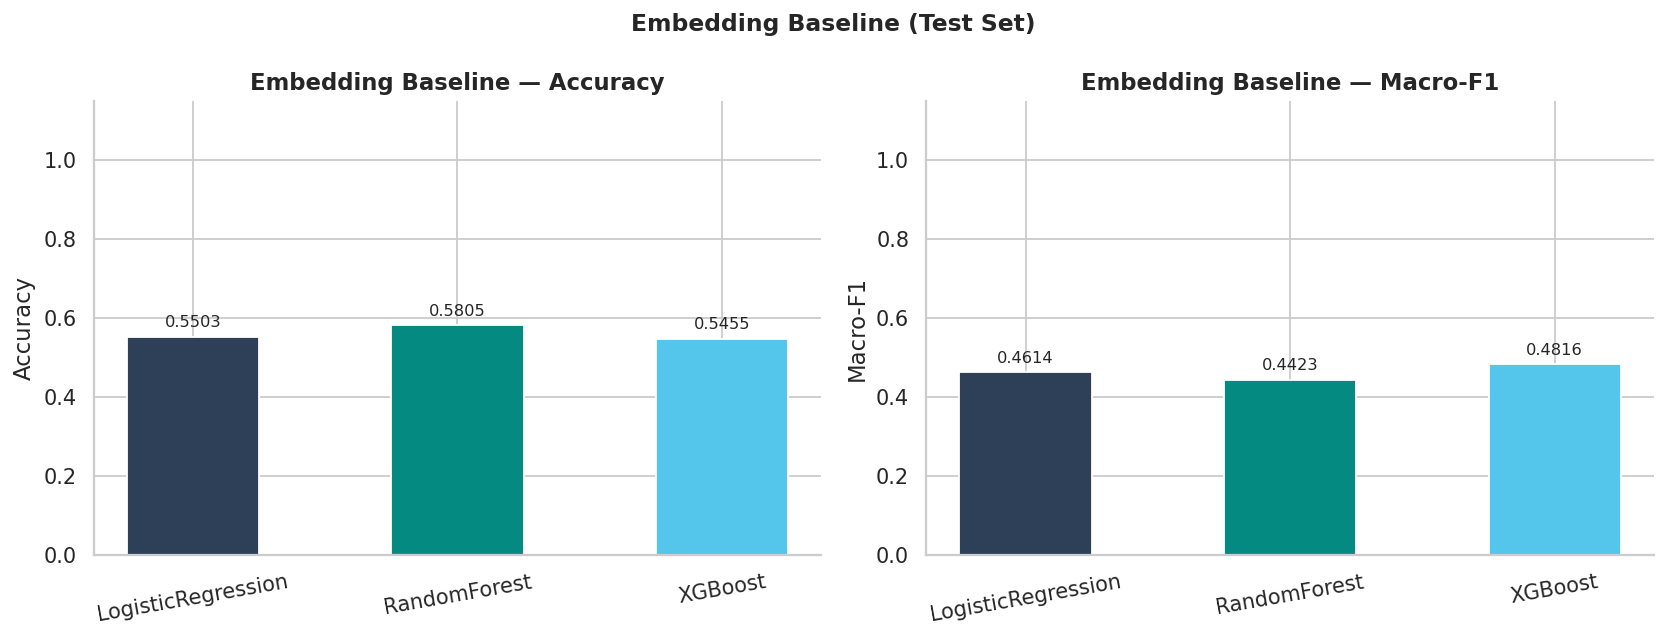

In [ ]:
# Bar chart — accuracy and macro-F1 side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    bars = ax.bar(df_baseline["model"], df_baseline[metric],
                  color=PALETTE[:len(df_baseline)], edgecolor="white", width=.5)
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_ylabel(title)
    ax.set_title(f"Embedding Baseline — {title}", fontweight="bold")
    ax.tick_params(axis="x", rotation=10)
plt.suptitle("Embedding Baseline (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGS, "baseline_embedding.png")); plt.show()


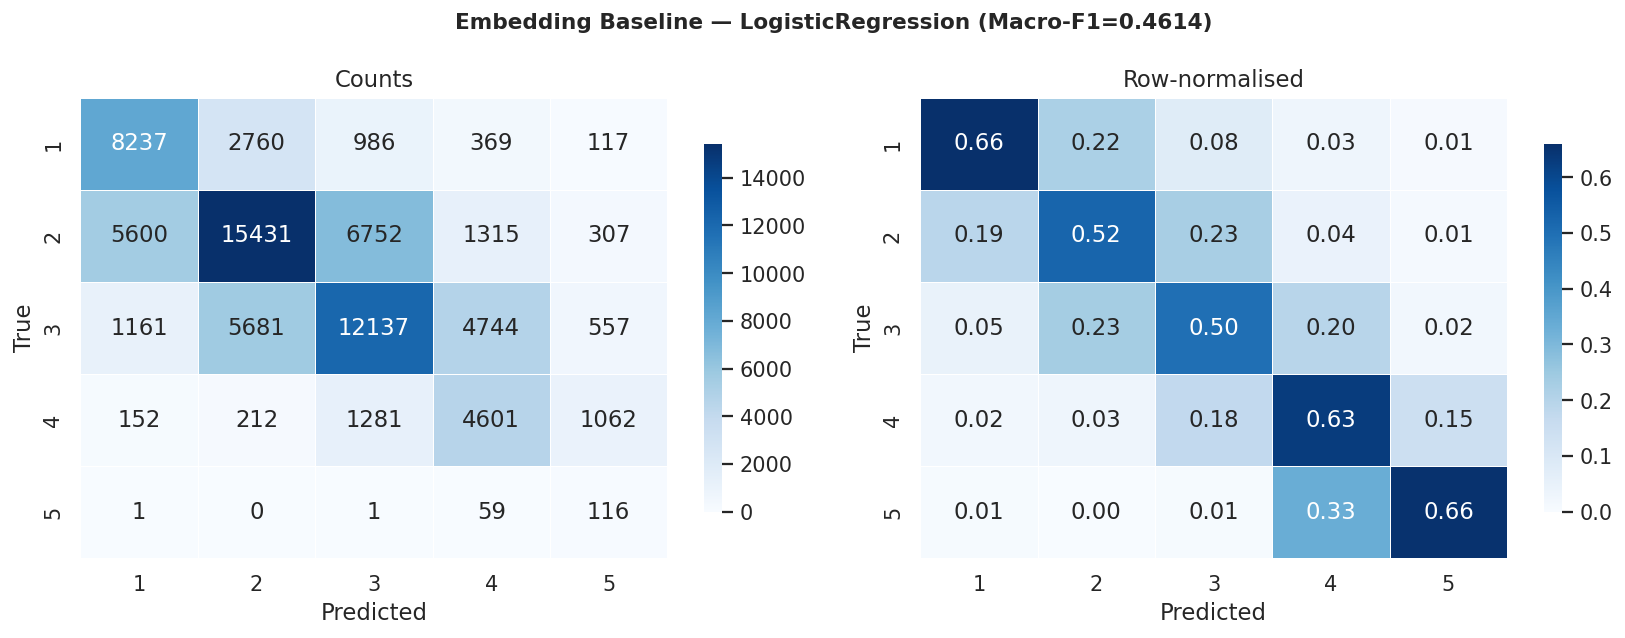

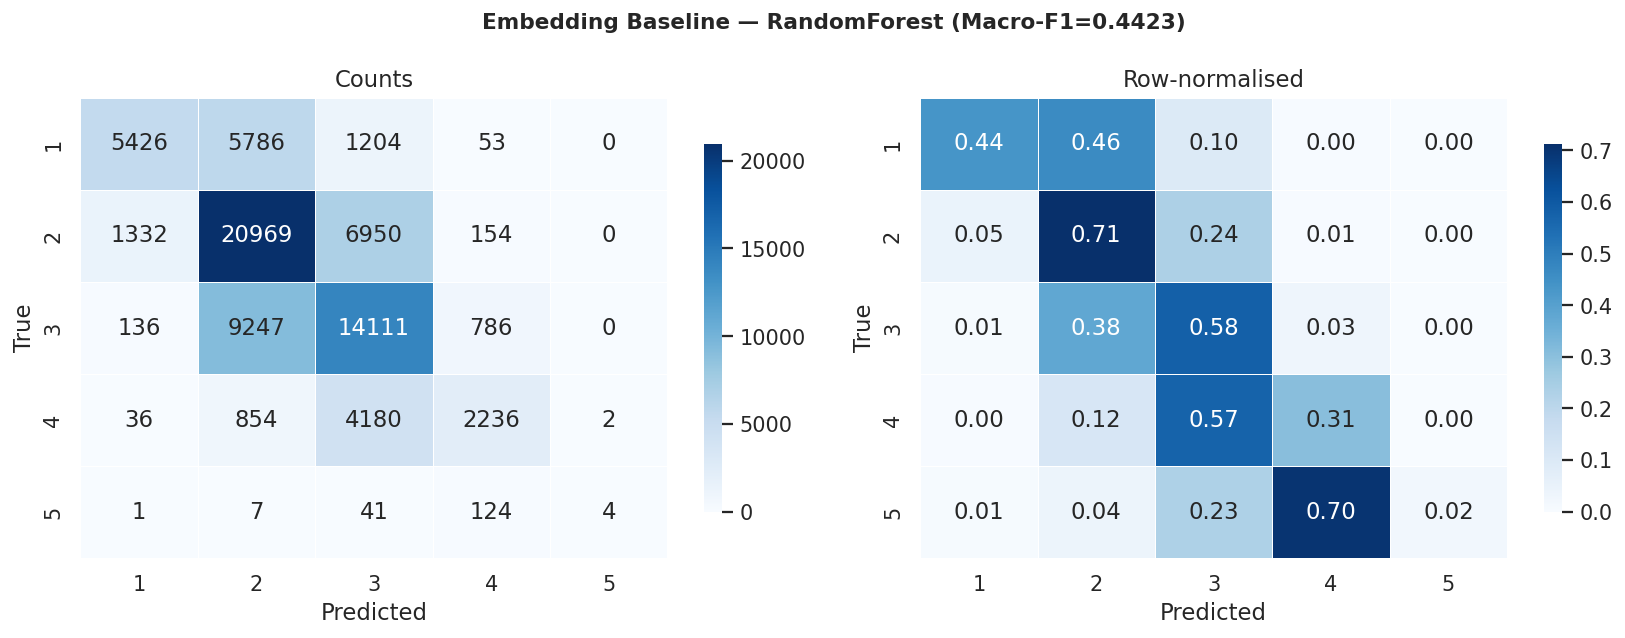

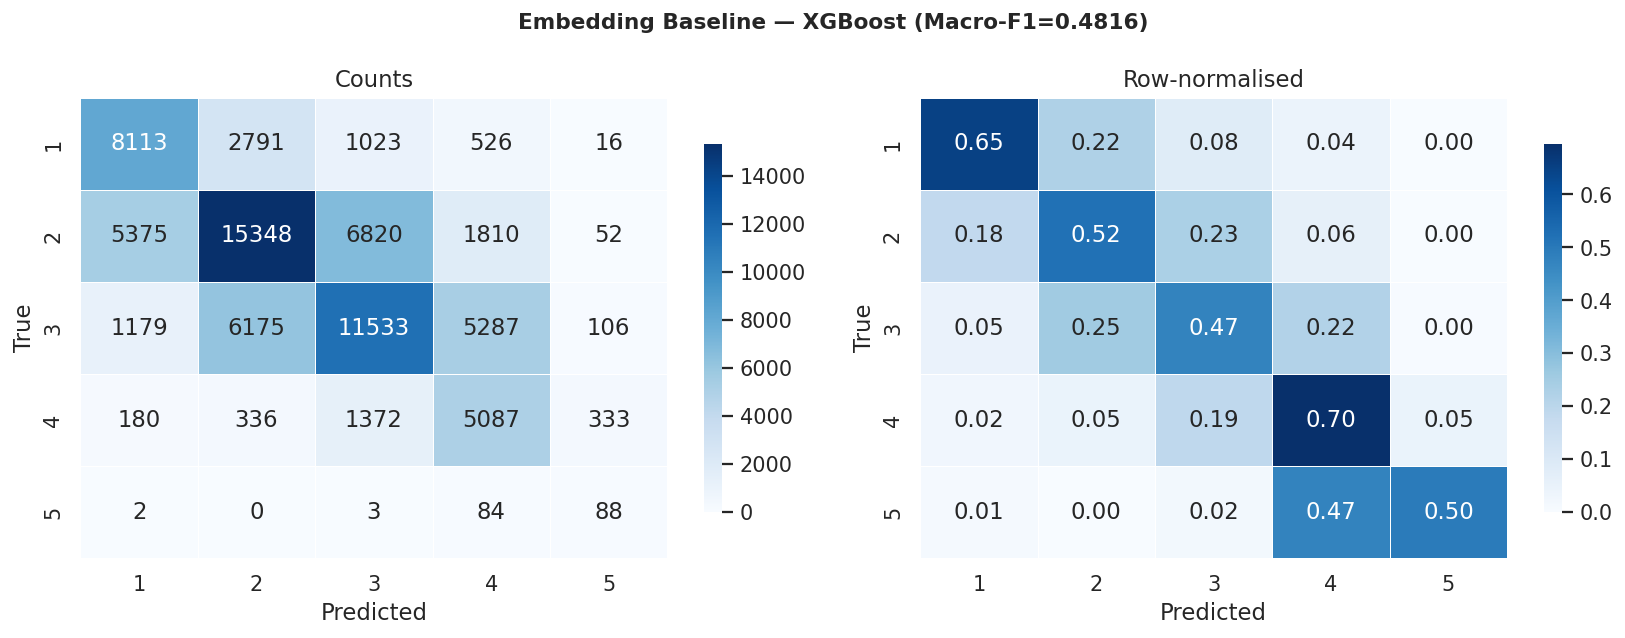

In [ ]:
# Confusion matrices for all three models
for r in baseline_results:
    plot_cm(r["cm"],
            f"Embedding Baseline — {r['model']} (Macro-F1={r['macro_f1']:.4f})",
            f"baseline_cm_{r['model'].lower()}.png")


## 13. Code Truncation Experiment (Test Set, RF + XGBoost)

To test if early code matter more than the full snippet
Tests first 10 lines / first 30 lines / full code.  
Best truncation = highest average macro-F1 across RF and XGBoost.


In [ ]:
CACHE_TRUNC = os.path.join(DRIVE_SAVE_DIR, "trunc_embeddings.npz")

if os.path.exists(CACHE_TRUNC):
    print("Loading truncation embeddings from Drive...")
    cache     = np.load(CACHE_TRUNC)
    trunc_emb = {name: {"tr": cache[f"{name}_tr"], "te": cache[f"{name}_te"]}
                 for name in TRUNCATION_OPTIONS}
    print("Loaded from cache.")
else:
    trunc_emb, save_dict = {}, {}
    for name, n_lines in TRUNCATION_OPTIONS.items():
        print(f"  Extracting [{name}]  (n_lines={n_lines})...")
        tr = extract_embeddings(df_train["code"].tolist(), encoder, tokenizer,
                                BEST_MAX_LEN, BEST_POOLING, n_lines)
        te = extract_embeddings(df_test["code"].tolist(),  encoder, tokenizer,
                                BEST_MAX_LEN, BEST_POOLING, n_lines)
        trunc_emb[name] = {"tr": tr, "te": te}
        save_dict[f"{name}_tr"] = tr
        save_dict[f"{name}_te"] = te
    np.savez_compressed(CACHE_TRUNC, **save_dict)
    print(f"Saved to {CACHE_TRUNC}")


  Extracting [first_10]  (n_lines=10)...
  640/343644 embedded...
  1280/343644 embedded...
  1920/343644 embedded...
  2560/343644 embedded...
  3200/343644 embedded...
  3840/343644 embedded...
  4480/343644 embedded...
  5120/343644 embedded...
  5760/343644 embedded...
  6400/343644 embedded...
  7040/343644 embedded...
  7680/343644 embedded...
  8320/343644 embedded...
  8960/343644 embedded...
  9600/343644 embedded...
  10240/343644 embedded...
  10880/343644 embedded...
  11520/343644 embedded...
  12160/343644 embedded...
  12800/343644 embedded...
  13440/343644 embedded...
  14080/343644 embedded...
  14720/343644 embedded...
  15360/343644 embedded...
  16000/343644 embedded...
  16640/343644 embedded...
  17280/343644 embedded...
  17920/343644 embedded...
  18560/343644 embedded...
  19200/343644 embedded...
  19840/343644 embedded...
  20480/343644 embedded...
  21120/343644 embedded...
  21760/343644 embedded...
  22400/343644 embedded...
  23040/343644 embedded...
  2

In [ ]:
trunc_results = []
print(f"{'Truncation':<12} {'Model':<20} {'Accuracy':>10} {'Macro-F1':>10}")
print("-" * 56)

for trunc_name in TRUNCATION_OPTIONS:
    X_tr_t = trunc_emb[trunc_name]["tr"]
    X_te_t = trunc_emb[trunc_name]["te"]
    row    = {"truncation": trunc_name}
    f1s    = []
    for clf_name in ["RandomForest", "XGBoost"]:
        y_pred = fit_predict(clf_name, X_tr_t, y_tr, X_te_t)
        m      = full_eval(y_te, y_pred)
        row[f"{clf_name}_accuracy"] = m["accuracy"]
        row[f"{clf_name}_macro_f1"] = m["macro_f1"]
        row[f"{clf_name}_cm"]       = m["cm"]
        f1s.append(m["macro_f1"])
        print(f"{trunc_name:<12} {clf_name:<20} {m['accuracy']:>10.4f} {m['macro_f1']:>10.4f}")
    row["avg_macro_f1"] = round(float(np.mean(f1s)), 4)
    print(f"{trunc_name:<12} {'-- Average --':<20} {'':>10} {row['avg_macro_f1']:>10.4f}")
    print()
    trunc_results.append(row)

best_truncation = max(trunc_results, key=lambda x: x["avg_macro_f1"])["truncation"]
best_n_lines    = TRUNCATION_OPTIONS[best_truncation]
print(f"Best truncation : {best_truncation}  (n_lines={best_n_lines})")
print("(selected by average RF + XGBoost macro-F1)")


Truncation   Model                  Accuracy   Macro-F1
--------------------------------------------------------
first_10     RandomForest             0.5387     0.4016
first_10     XGBoost                  0.5008     0.4312
first_10     -- Average --                       0.4164

first_30     RandomForest             0.5774     0.4389
first_30     XGBoost                  0.5433     0.4793
first_30     -- Average --                       0.4591

full         RandomForest             0.5805     0.4423
full         XGBoost                  0.5455     0.4816
full         -- Average --                       0.4619

Best truncation : full  (n_lines=None)
(selected by average RF + XGBoost macro-F1)


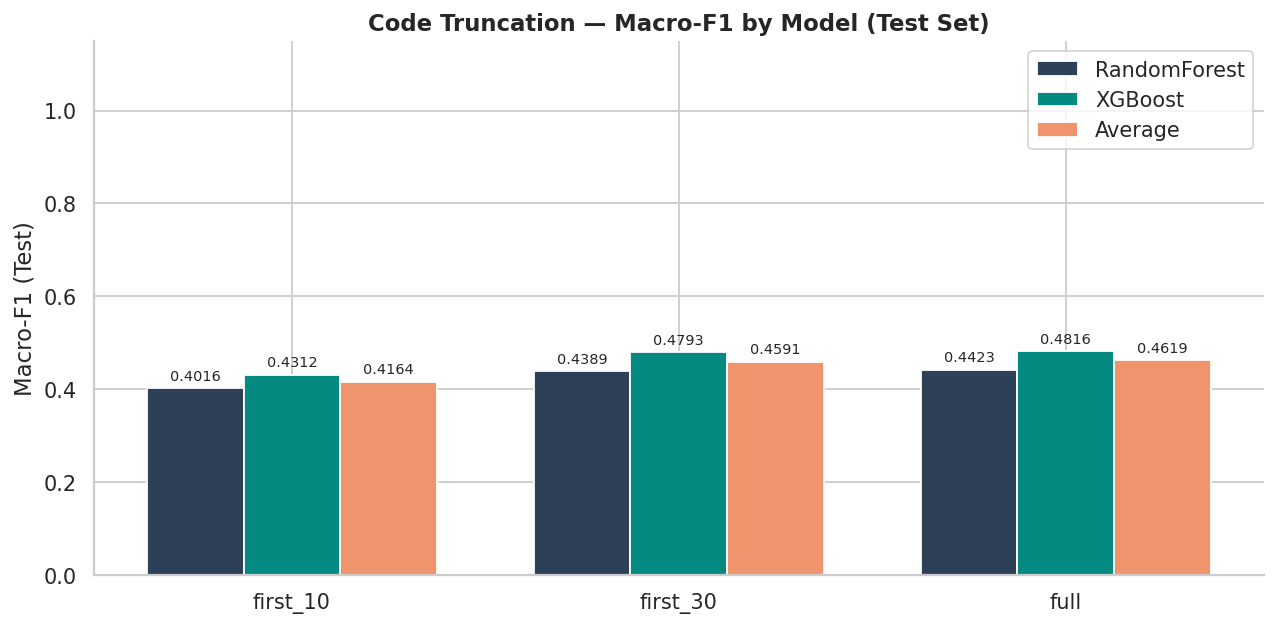

In [ ]:
# Grouped bar: RF vs XGBoost vs Average per truncation
trunc_names = [r["truncation"] for r in trunc_results]
rf_f1s      = [r["RandomForest_macro_f1"] for r in trunc_results]
xgb_f1s     = [r["XGBoost_macro_f1"]     for r in trunc_results]
avg_f1s     = [r["avg_macro_f1"]          for r in trunc_results]

x = np.arange(len(trunc_names)); w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w,   rf_f1s,  w, label="RandomForest", color=PALETTE[0], edgecolor="white")
b2 = ax.bar(x,       xgb_f1s, w, label="XGBoost",      color=PALETTE[1], edgecolor="white")
b3 = ax.bar(x + w,   avg_f1s, w, label="Average",       color=PALETTE[3], edgecolor="white")
for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(trunc_names)
ax.set_ylim(0, 1.15); ax.set_ylabel("Macro-F1 (Test)")
ax.set_title("Code Truncation — Macro-F1 by Model (Test Set)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS, "truncation_bar.png")); plt.show()


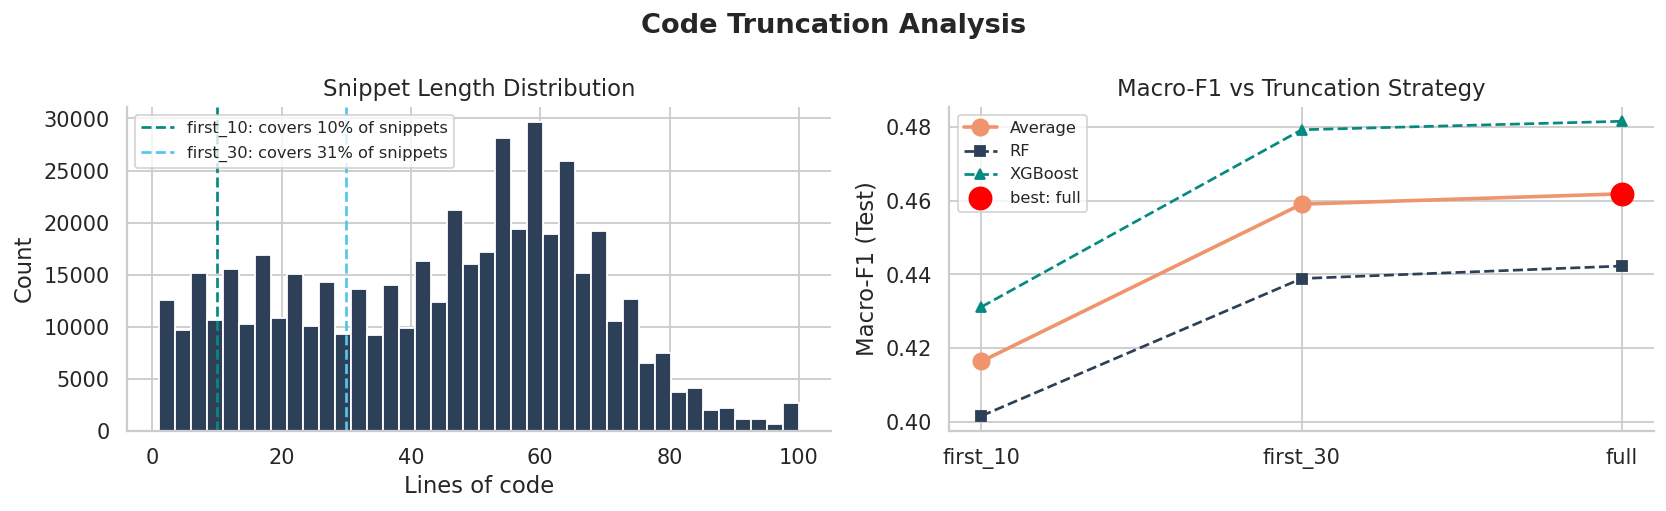

In [ ]:
# Snippet length distribution — coverage at each cutoff
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Code Truncation Analysis", fontweight="bold")

line_counts = df["code"].apply(lambda c: len(c.split("\n")))
axes[0].hist(line_counts.clip(upper=100), bins=40, color=PALETTE[0], edgecolor="white")
axes[0].set_title("Snippet Length Distribution")
axes[0].set_xlabel("Lines of code"); axes[0].set_ylabel("Count")
for nl, col in zip([10, 30], PALETTE[1:]):
    pct = (line_counts <= nl).mean() * 100
    axes[0].axvline(nl, linestyle="--", linewidth=1.5, color=col,
                    label=f"first_{nl}: covers {pct:.0f}% of snippets")
axes[0].legend(fontsize=9)

axes[1].plot(trunc_names, avg_f1s,  marker="o", linewidth=2, markersize=9,
             color=PALETTE[3], label="Average", zorder=3)
axes[1].plot(trunc_names, rf_f1s,   marker="s", linewidth=1.5, markersize=6,
             color=PALETTE[0], linestyle="--", label="RF")
axes[1].plot(trunc_names, xgb_f1s,  marker="^", linewidth=1.5, markersize=6,
             color=PALETTE[1], linestyle="--", label="XGBoost")
best_avg = next(r["avg_macro_f1"] for r in trunc_results if r["truncation"]==best_truncation)
axes[1].scatter([best_truncation], [best_avg], color="red", s=150, zorder=5,
                label=f"best: {best_truncation}")
axes[1].set_title("Macro-F1 vs Truncation Strategy")
axes[1].set_ylabel("Macro-F1 (Test)"); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, "truncation_coverage.png")); plt.show()


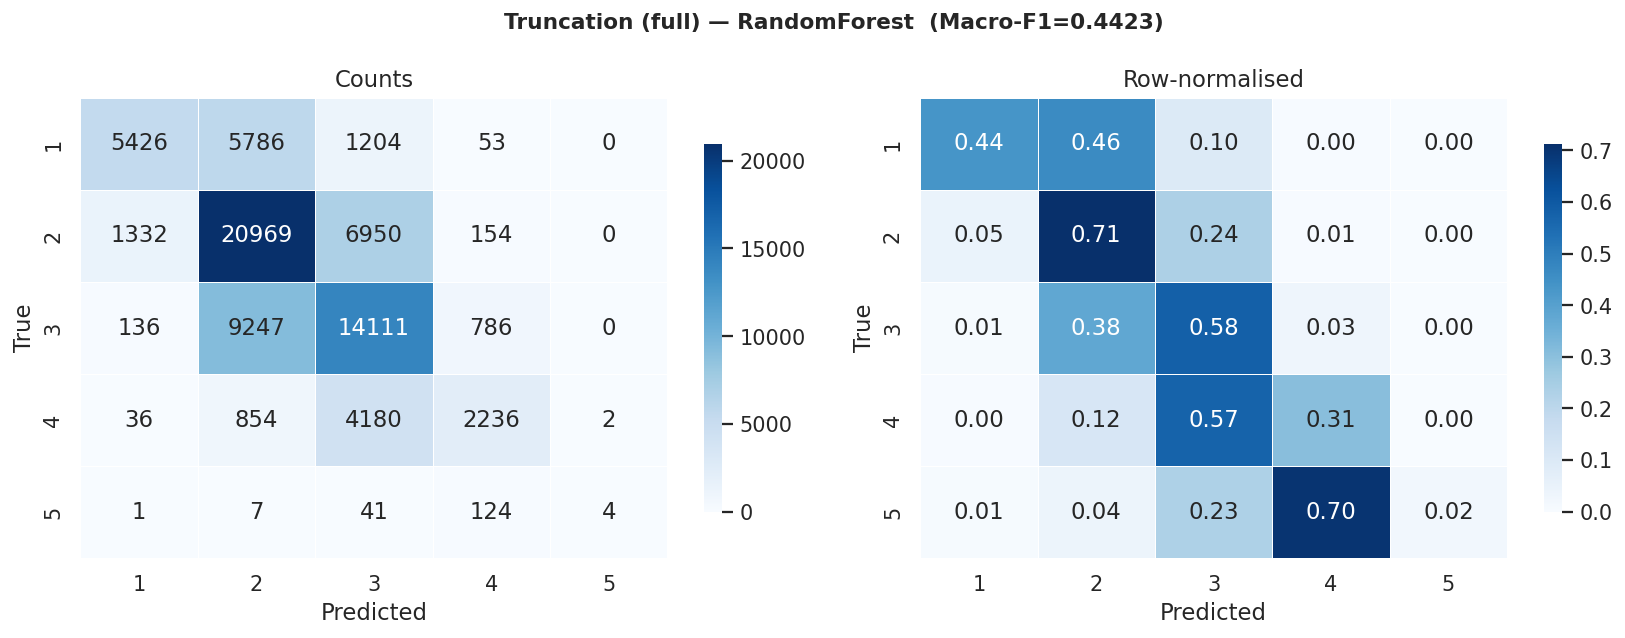

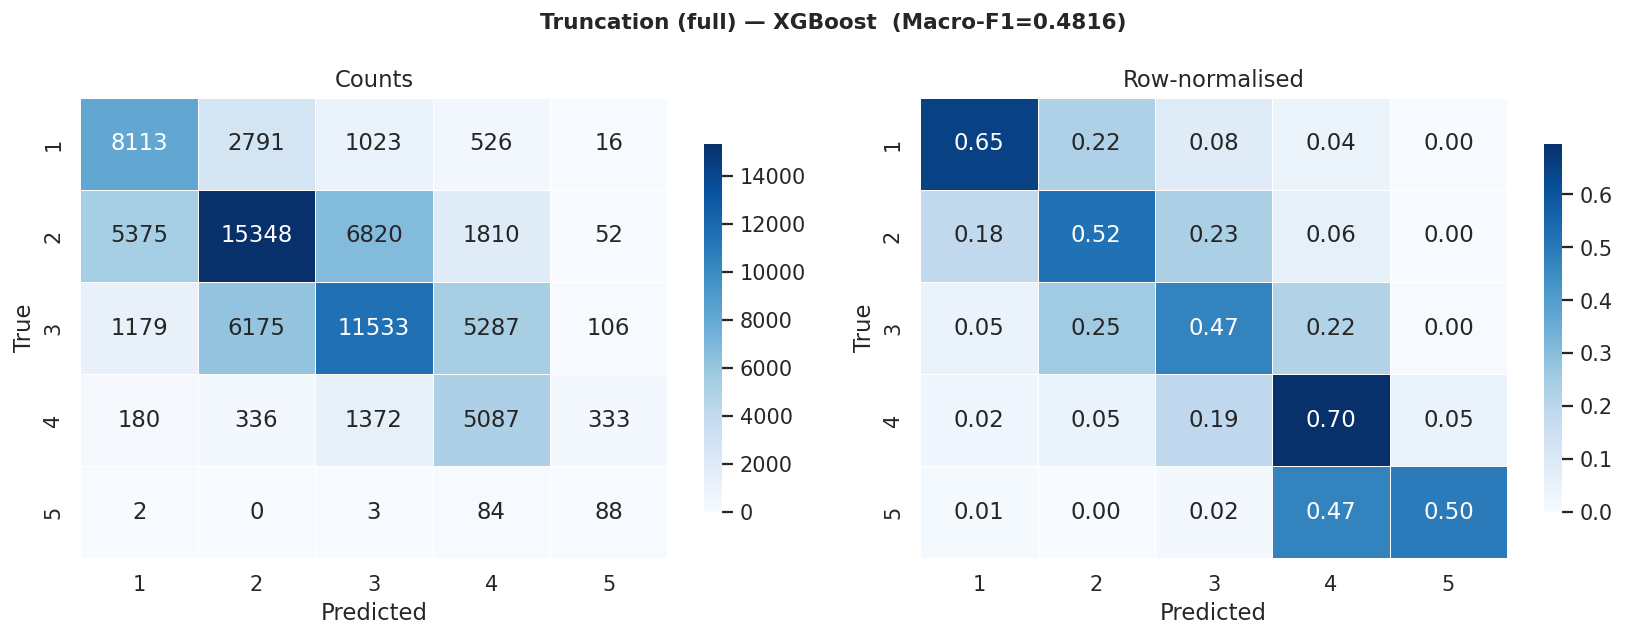

In [ ]:
# Confusion matrices for best truncation
best_trunc_row = next(r for r in trunc_results if r["truncation"] == best_truncation)
for clf_name in ["RandomForest", "XGBoost"]:
    plot_cm(best_trunc_row[f"{clf_name}_cm"],
            f"Truncation ({best_truncation}) — {clf_name}  "
            f"(Macro-F1={best_trunc_row[f'{clf_name}_macro_f1']:.4f})",
            f"truncation_cm_{clf_name.lower()}_{best_truncation}.png")


## 14. Class Imbalance Strategies (Embedding-only, RF, Test Set)



In [ ]:
min_class = min(np.bincount(y_tr - 1))
print(f"Smallest class size in training set: {min_class}")

strategies = {
    "Raw":           (X_emb_tr, y_tr, None),
    "Class weights": (X_emb_tr, y_tr, "balanced"),
}

ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_emb_tr, y_tr)
strategies["Over-Sampling"] = (X_ros, y_ros, None)

if min_class >= 6:
    smote = SMOTE(random_state=42, k_neighbors=min(5, min_class - 1))
    X_sm, y_sm = smote.fit_resample(X_emb_tr, y_tr)
    strategies["SMOTE"] = (X_sm, y_sm, None)
else:
    print(f"Skipping SMOTE — smallest class has only {min_class} samples")

imbalance_results = []
print(f"\n{'Strategy':<20} {'Accuracy':>10} {'Macro-F1':>10}")
print("-" * 42)

for strat_name, (X_tr_s, y_tr_s, cw) in strategies.items():
    rf = build_rf(class_weight=cw)
    rf = build_rf(class_weight=cw if cw is not None else None)
    rf.fit(X_tr_s, y_tr_s)
    y_pred = rf.predict(X_emb_te)
    m = full_eval(y_te, y_pred)
    m["strategy"] = strat_name
    imbalance_results.append(m)
    print(f"{strat_name:<20} {m['accuracy']:>10.4f} {m['macro_f1']:>10.4f}")


Smallest class size in training set: 827

Strategy               Accuracy   Macro-F1
------------------------------------------
Raw                      0.5835     0.4382
Class weights            0.5805     0.4423
Over-Sampling            0.5826     0.4613
SMOTE                    0.5667     0.4712


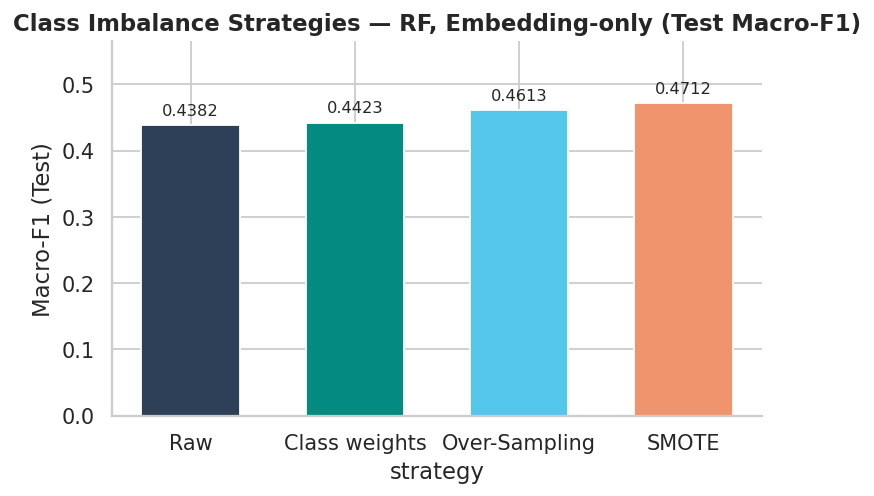

In [ ]:
simple_bar(imbalance_results, "strategy", "macro_f1",
           "Class Imbalance Strategies — RF, Embedding-only (Test Macro-F1)",
           "imbalance_bar.png",
           colors=PALETTE[:len(imbalance_results)])


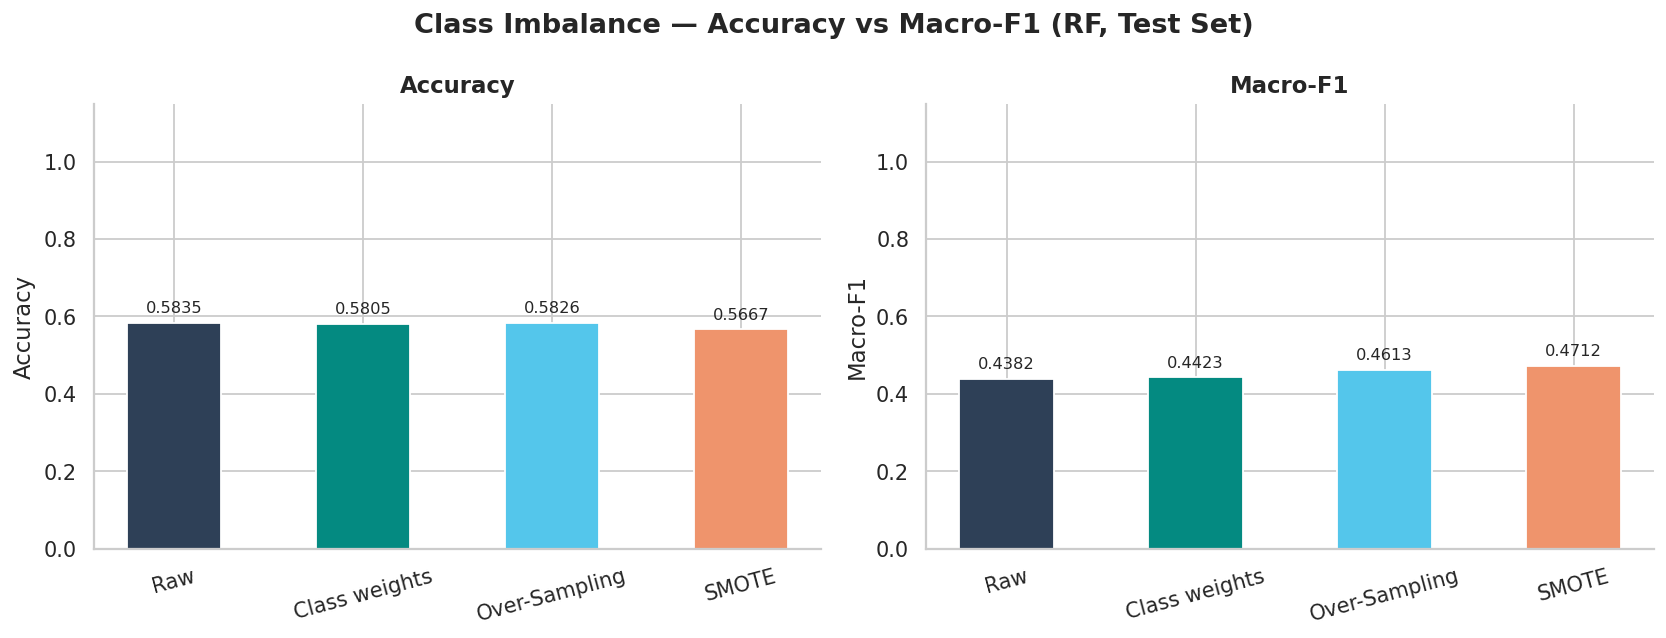

In [ ]:
# Accuracy vs Macro-F1 comparison across strategies
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Class Imbalance — Accuracy vs Macro-F1 (RF, Test Set)", fontweight="bold")
for ax, metric, title in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    bars = ax.bar([r["strategy"] for r in imbalance_results],
                  [r[metric] for r in imbalance_results],
                  color=PALETTE[:len(imbalance_results)], edgecolor="white", width=.5)
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_ylabel(title)
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, "imbalance_acc_f1.png")); plt.show()


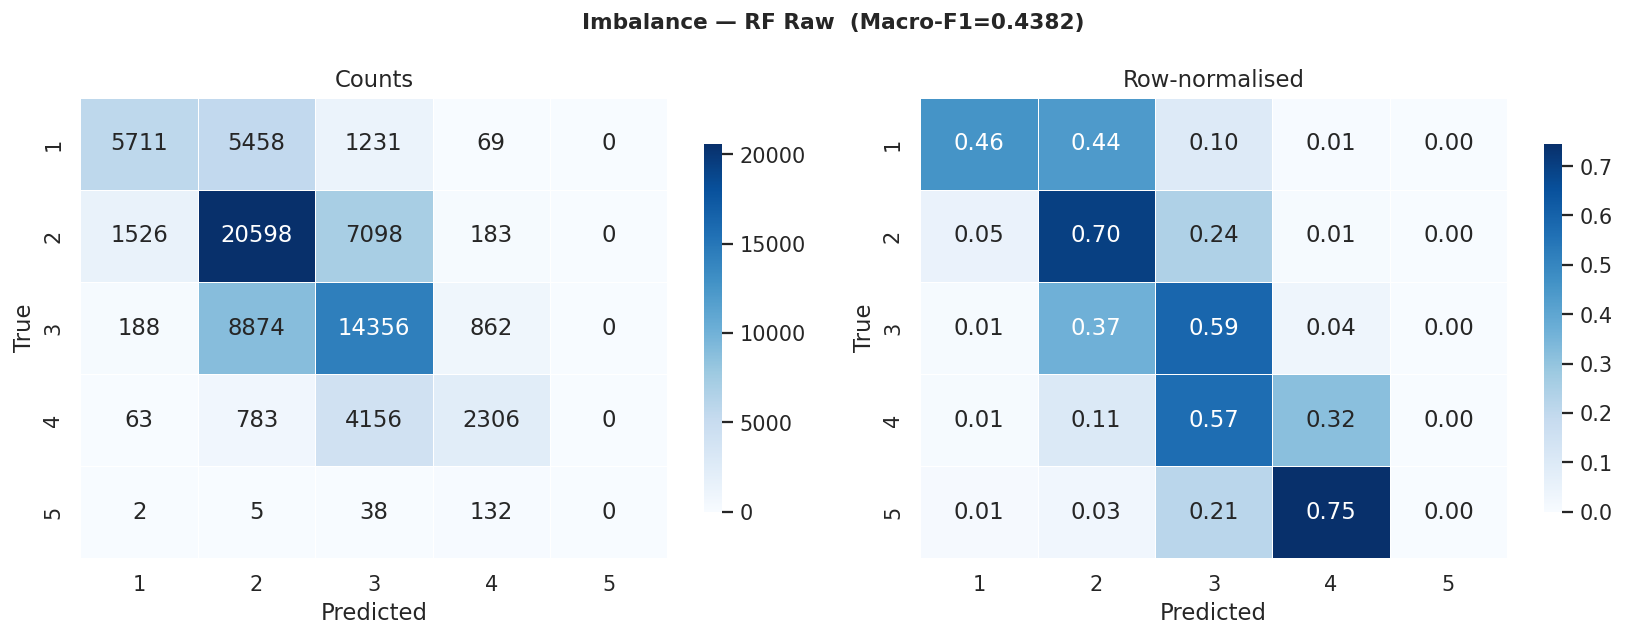

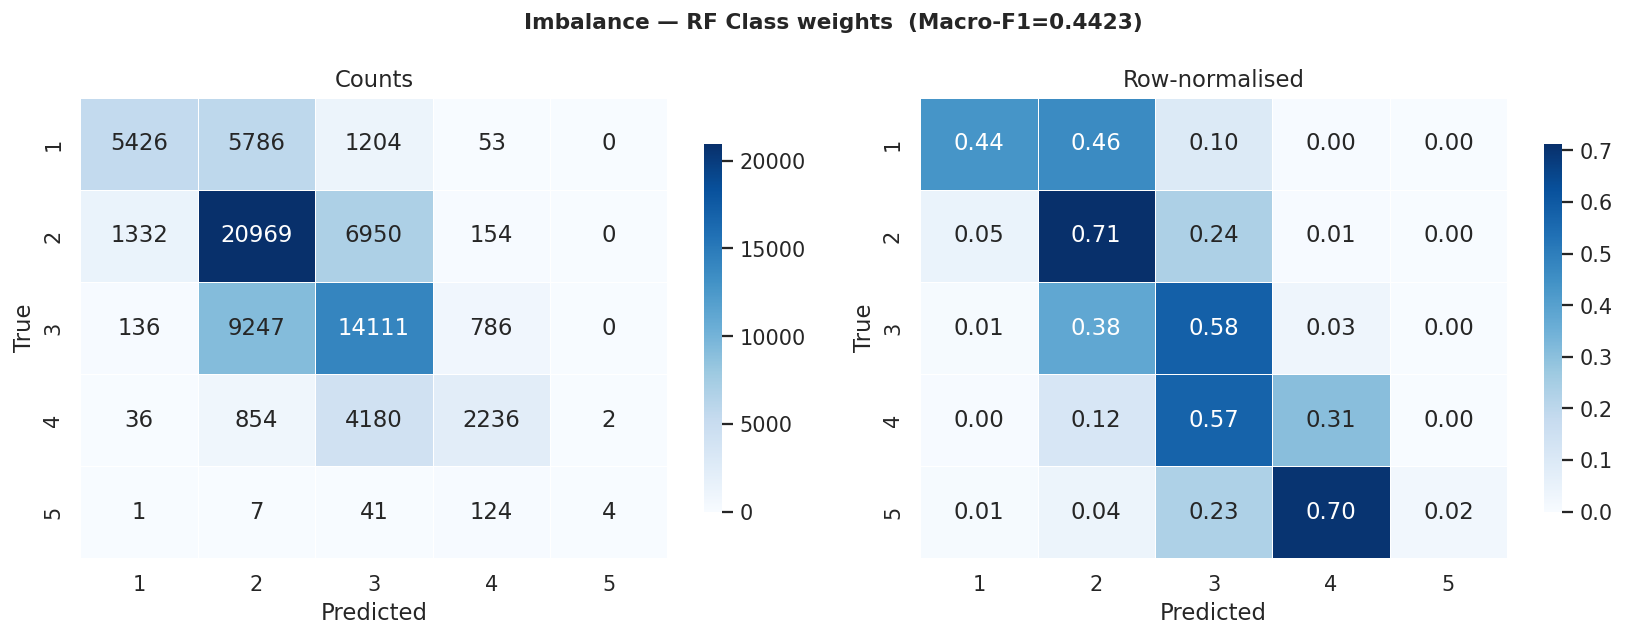

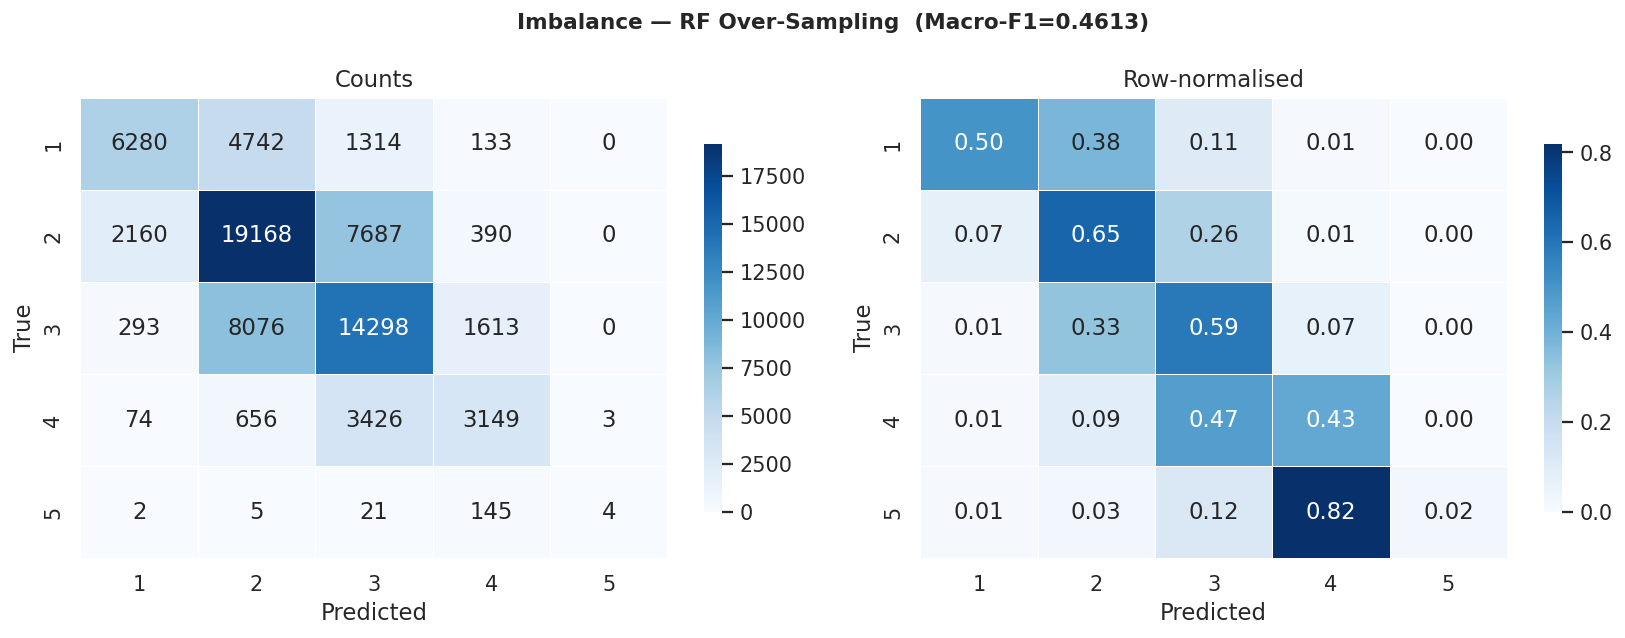

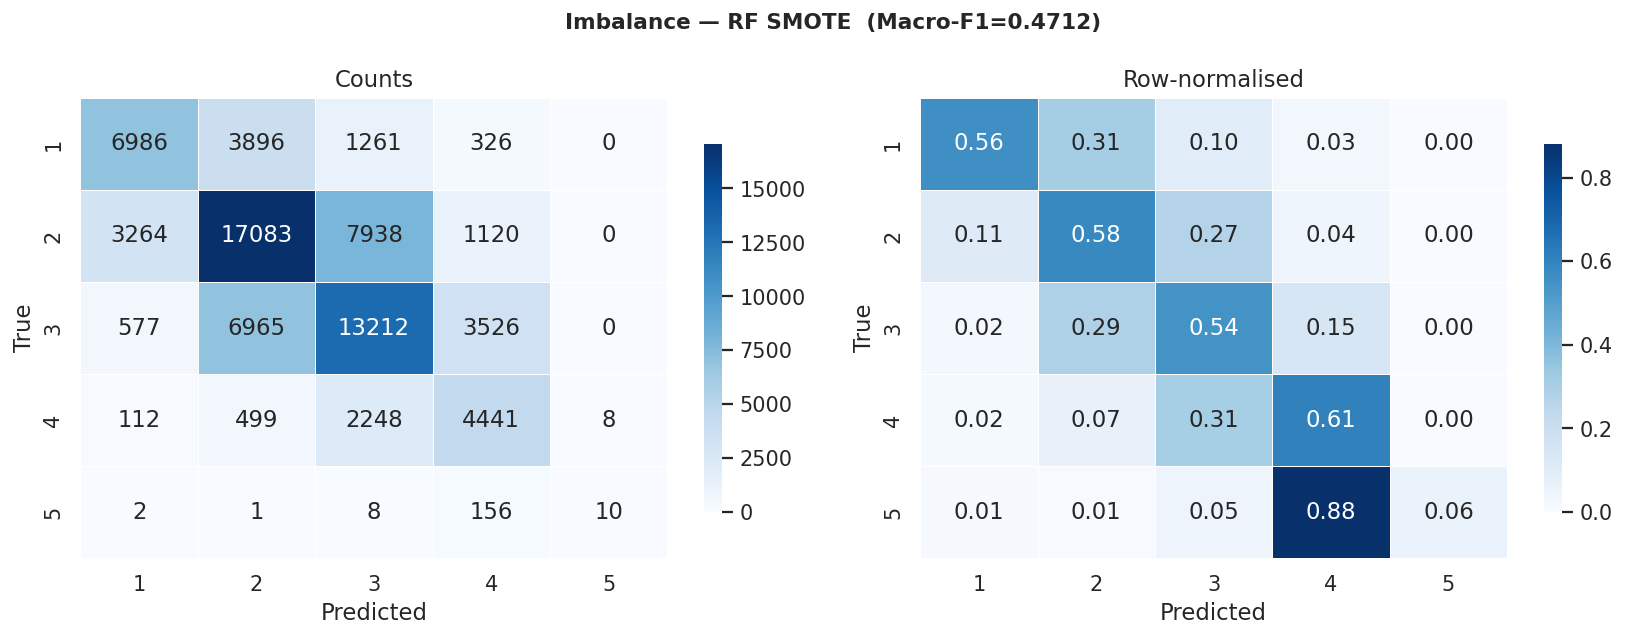

In [ ]:
# Confusion matrix per strategy
for r in imbalance_results:
    plot_cm(r["cm"],
            f"Imbalance — RF {r['strategy']}  (Macro-F1={r['macro_f1']:.4f})",
            f"imbalance_cm_{r['strategy'].replace(' ','_').lower()}.png")


## 15. Feature-only vs Embedding-only Comparison (Test Set)

Head-to-head comparison of both approaches across all three classifiers.
Same train/test split, same classifiers, same evaluation.


In [ ]:
print("=== Feature-only models ===")
fo_results = []
for clf_name in CLASSIFIERS:
    print(f"  {clf_name}...", flush=True)
    y_pred = fit_predict(clf_name, X_fo_tr, y_tr, X_fo_te)
    m      = full_eval(y_te, y_pred)
    m["condition"] = "Feature-only"
    m["model"]     = clf_name
    fo_results.append(m)
    print(f"    Accuracy={m['accuracy']:.4f}  Macro-F1={m['macro_f1']:.4f}")

print("\n=== Embedding-only models ===")
emb_results = []
for clf_name in CLASSIFIERS:
    print(f"  {clf_name}...", flush=True)
    y_pred = fit_predict(clf_name, X_emb_tr, y_tr, X_emb_te)
    m      = full_eval(y_te, y_pred)
    m["condition"] = "Embedding-only"
    m["model"]     = clf_name
    emb_results.append(m)
    print(f"    Accuracy={m['accuracy']:.4f}  Macro-F1={m['macro_f1']:.4f}")

all_comparison = fo_results + emb_results
df_comp = pd.DataFrame([{k: v for k, v in r.items() if k != "cm"}
                         for r in all_comparison])
print("\n", df_comp.to_string(index=False))


=== Feature-only models ===
  LogisticRegression...
    Accuracy=0.3673  Macro-F1=0.2971
  RandomForest...
    Accuracy=0.4707  Macro-F1=0.3585
  XGBoost...
    Accuracy=0.4456  Macro-F1=0.3731

=== Embedding-only models ===
  LogisticRegression...
    Accuracy=0.5503  Macro-F1=0.4614
  RandomForest...
    Accuracy=0.5805  Macro-F1=0.4423
  XGBoost...
    Accuracy=0.5455  Macro-F1=0.4816

  accuracy  macro_f1      condition              model
   0.3673    0.2971   Feature-only LogisticRegression
   0.4707    0.3585   Feature-only       RandomForest
   0.4456    0.3731   Feature-only            XGBoost
   0.5503    0.4614 Embedding-only LogisticRegression
   0.5805    0.4423 Embedding-only       RandomForest
   0.5455    0.4816 Embedding-only            XGBoost


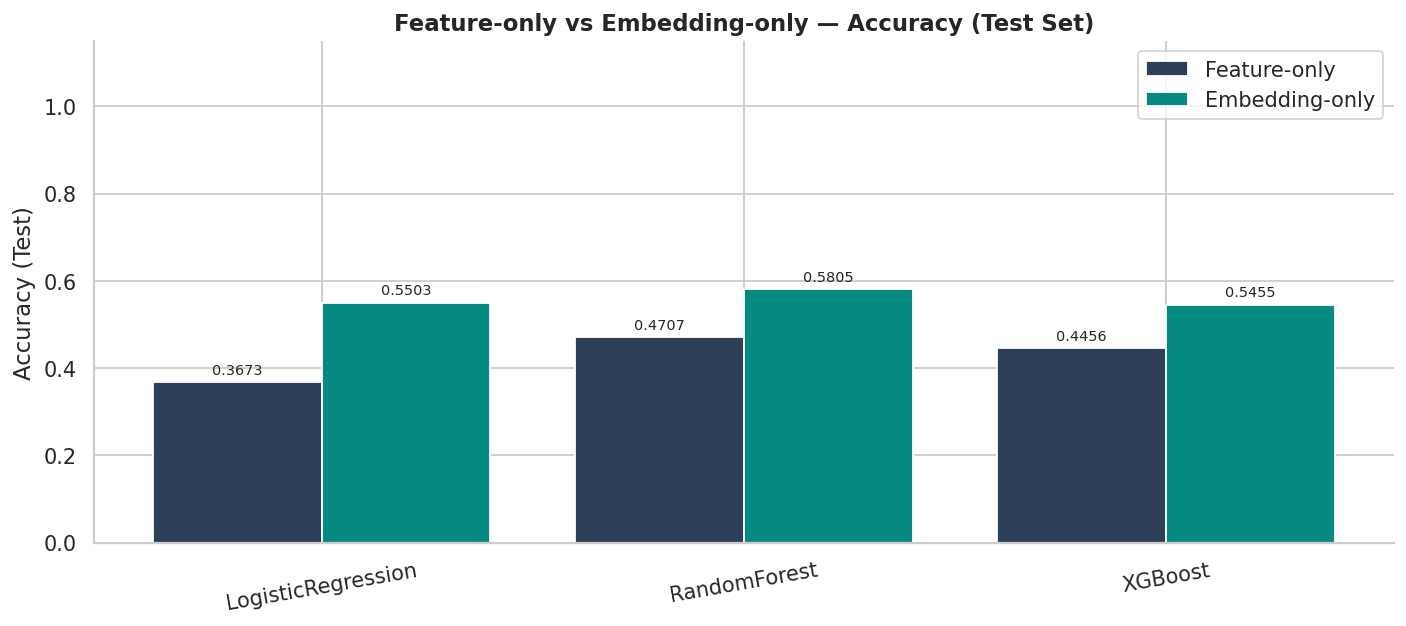

In [ ]:
# Grouped bar — Accuracy
grouped_bar(df_comp, "condition", "accuracy",
            "Feature-only vs Embedding-only — Accuracy (Test Set)",
            "comparison_accuracy.png",
            groups=["Feature-only", "Embedding-only"],
            ylabel="Accuracy (Test)")


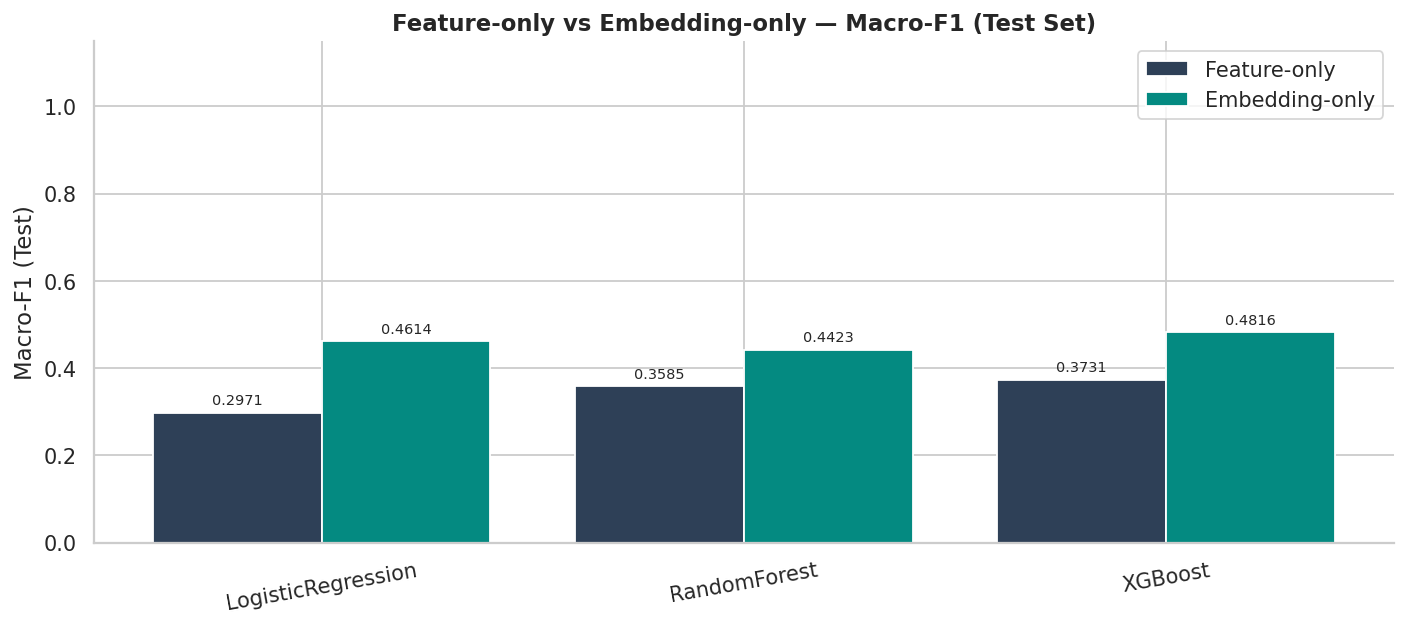

In [ ]:
# Grouped bar — Macro-F1
grouped_bar(df_comp, "condition", "macro_f1",
            "Feature-only vs Embedding-only — Macro-F1 (Test Set)",
            "comparison_macro_f1.png",
            groups=["Feature-only", "Embedding-only"],
            ylabel="Macro-F1 (Test)")


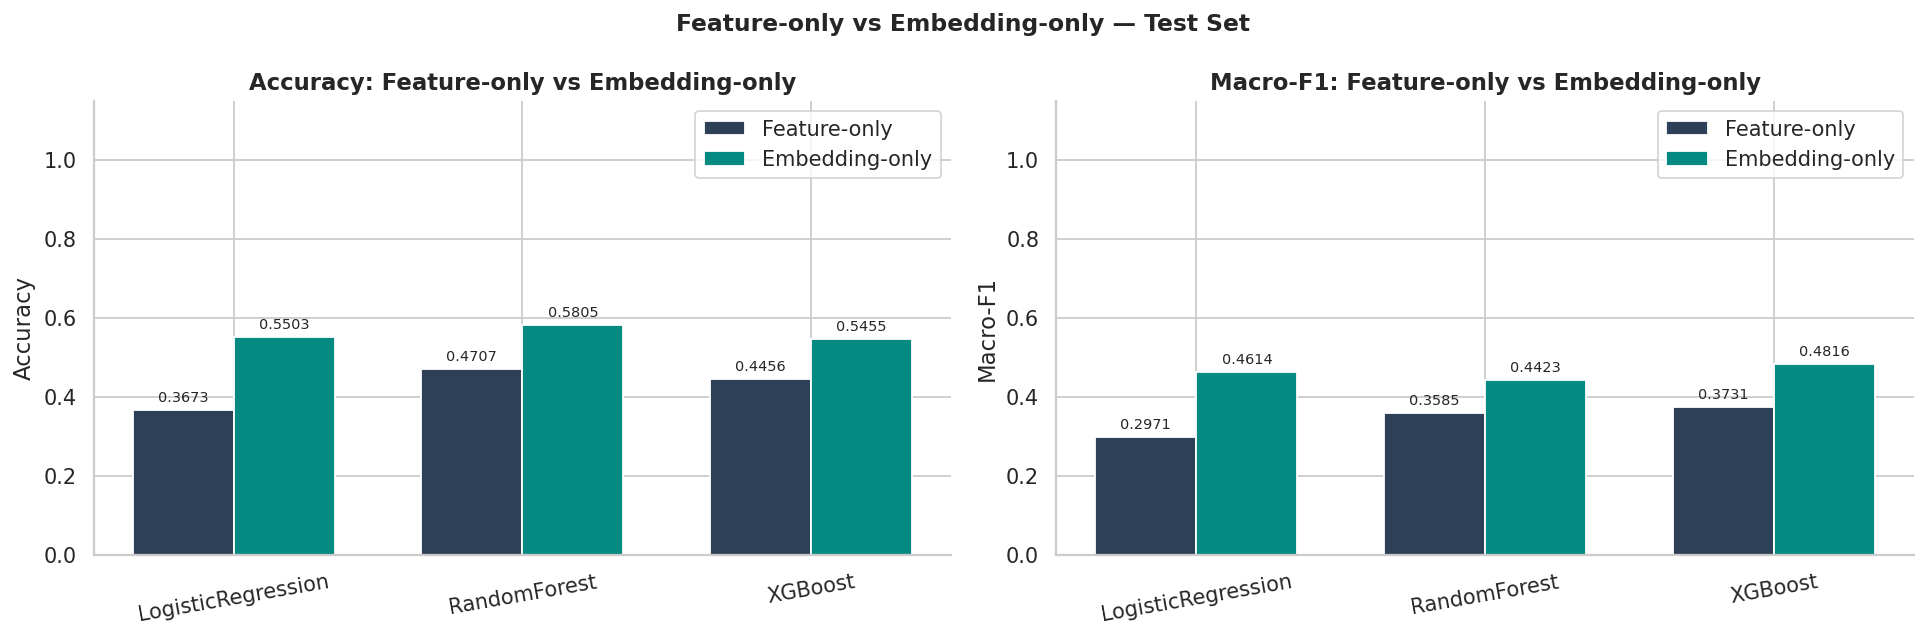

In [ ]:
# Combined accuracy + macro-F1 in one figure
clf_names  = list(CLASSIFIERS.keys())
conditions = ["Feature-only", "Embedding-only"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, title in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    x = np.arange(len(clf_names)); w = 0.35
    for i, cond in enumerate(conditions):
        vals = [df_comp[(df_comp["condition"]==cond) & (df_comp["model"]==c)][metric].values[0]
                for c in clf_names]
        bars = ax.bar(x + i*w, vals, w, label=cond, color=PALETTE[i], edgecolor="white")
        ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_xticks(x + w/2); ax.set_xticklabels(clf_names, rotation=10)
    ax.set_ylim(0, 1.15); ax.set_ylabel(title); ax.legend()
    ax.set_title(f"{title}: Feature-only vs Embedding-only", fontweight="bold")
plt.suptitle("Feature-only vs Embedding-only — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGS, "comparison_combined.png")); plt.show()


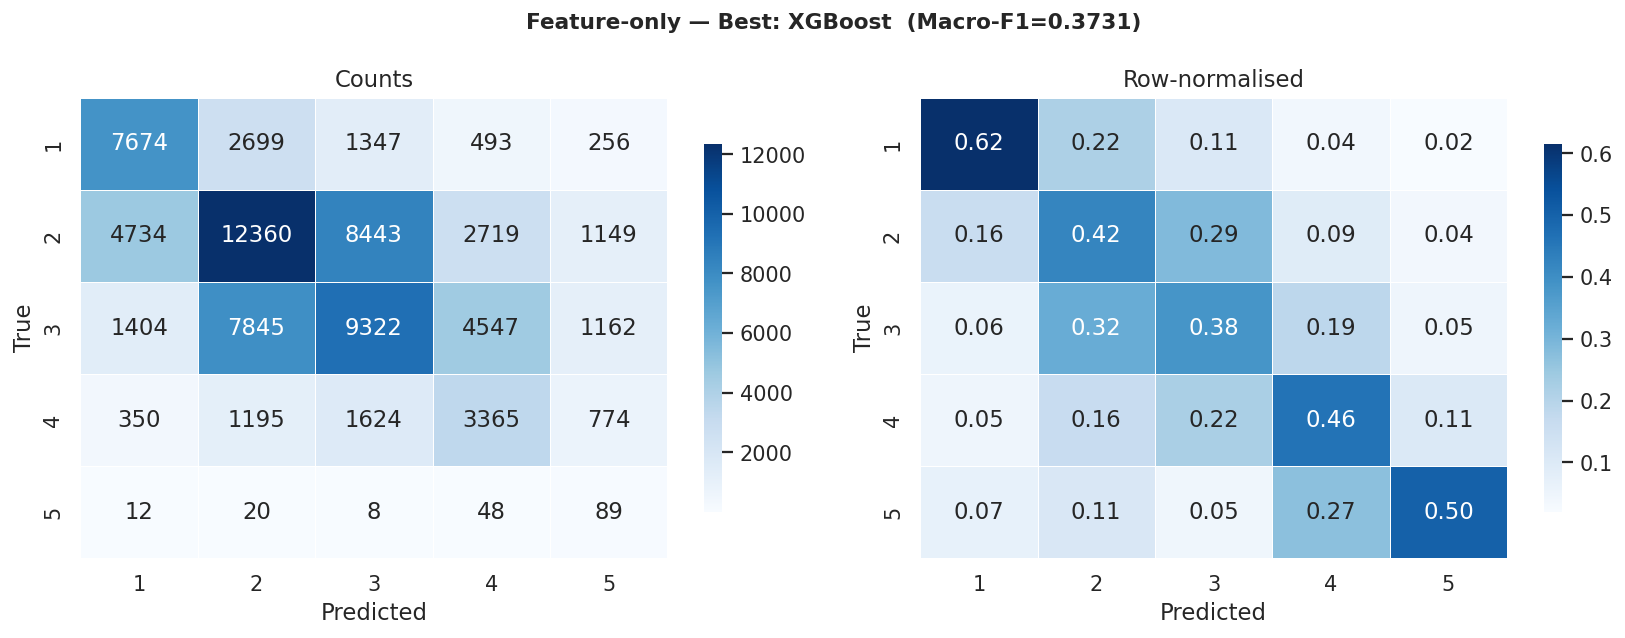

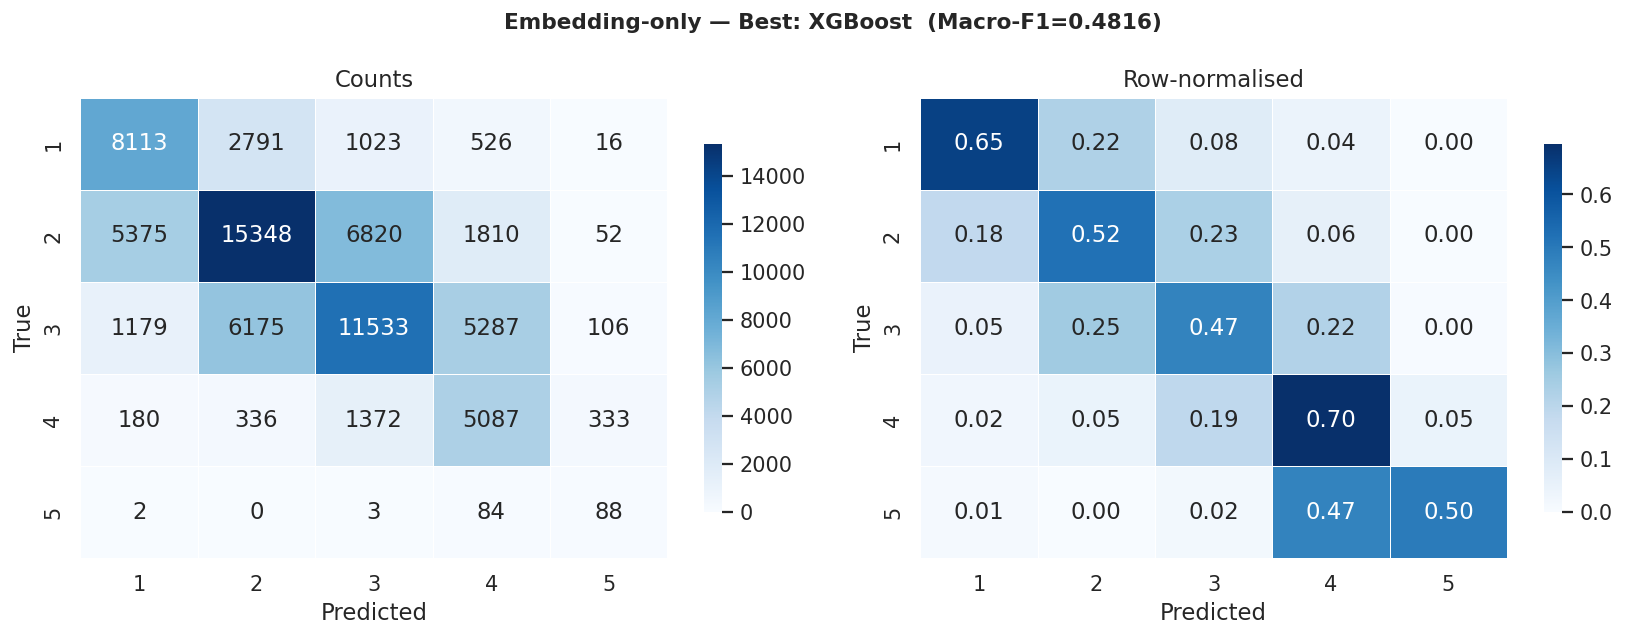

In [ ]:
# Confusion matrices — best model per condition
for cond, results in [("Feature-only", fo_results), ("Embedding-only", emb_results)]:
    best = max(results, key=lambda x: x["macro_f1"])
    plot_cm(best["cm"],
            f"{cond} — Best: {best['model']}  (Macro-F1={best['macro_f1']:.4f})",
            f"comparison_cm_{cond.replace('-','_').replace(' ','_').lower()}.png")


In [ ]:
# Delta table — how much does embedding gain/lose vs feature-only per model?
delta_rows = []
for clf_name in CLASSIFIERS:
    fo_f1  = next(r["macro_f1"] for r in fo_results  if r["model"]==clf_name)
    emb_f1 = next(r["macro_f1"] for r in emb_results if r["model"]==clf_name)
    fo_acc  = next(r["accuracy"] for r in fo_results  if r["model"]==clf_name)
    emb_acc = next(r["accuracy"] for r in emb_results if r["model"]==clf_name)
    delta_rows.append({
        "Model":           clf_name,
        "Feature Macro-F1":    fo_f1,
        "Embedding Macro-F1":  emb_f1,
        "Delta Macro-F1":      round(emb_f1 - fo_f1, 4),
        "Feature Accuracy":    fo_acc,
        "Embedding Accuracy":  emb_acc,
        "Delta Accuracy":      round(emb_acc - fo_acc, 4),
    })

df_delta = pd.DataFrame(delta_rows)
print(df_delta.to_string(index=False))
print("\n(positive Delta = Embedding-only wins, negative = Feature-only wins)")


             Model  Feature Macro-F1  Embedding Macro-F1  Delta Macro-F1  Feature Accuracy  Embedding Accuracy  Delta Accuracy
LogisticRegression            0.2971              0.4614          0.1643            0.3673              0.5503          0.1830
      RandomForest            0.3585              0.4423          0.0838            0.4707              0.5805          0.1098
           XGBoost            0.3731              0.4816          0.1085            0.4456              0.5455          0.0999

(positive Delta = Embedding-only wins, negative = Feature-only wins)


## 16. Save All Results

Results saved to: /content/results/file3_results.csv


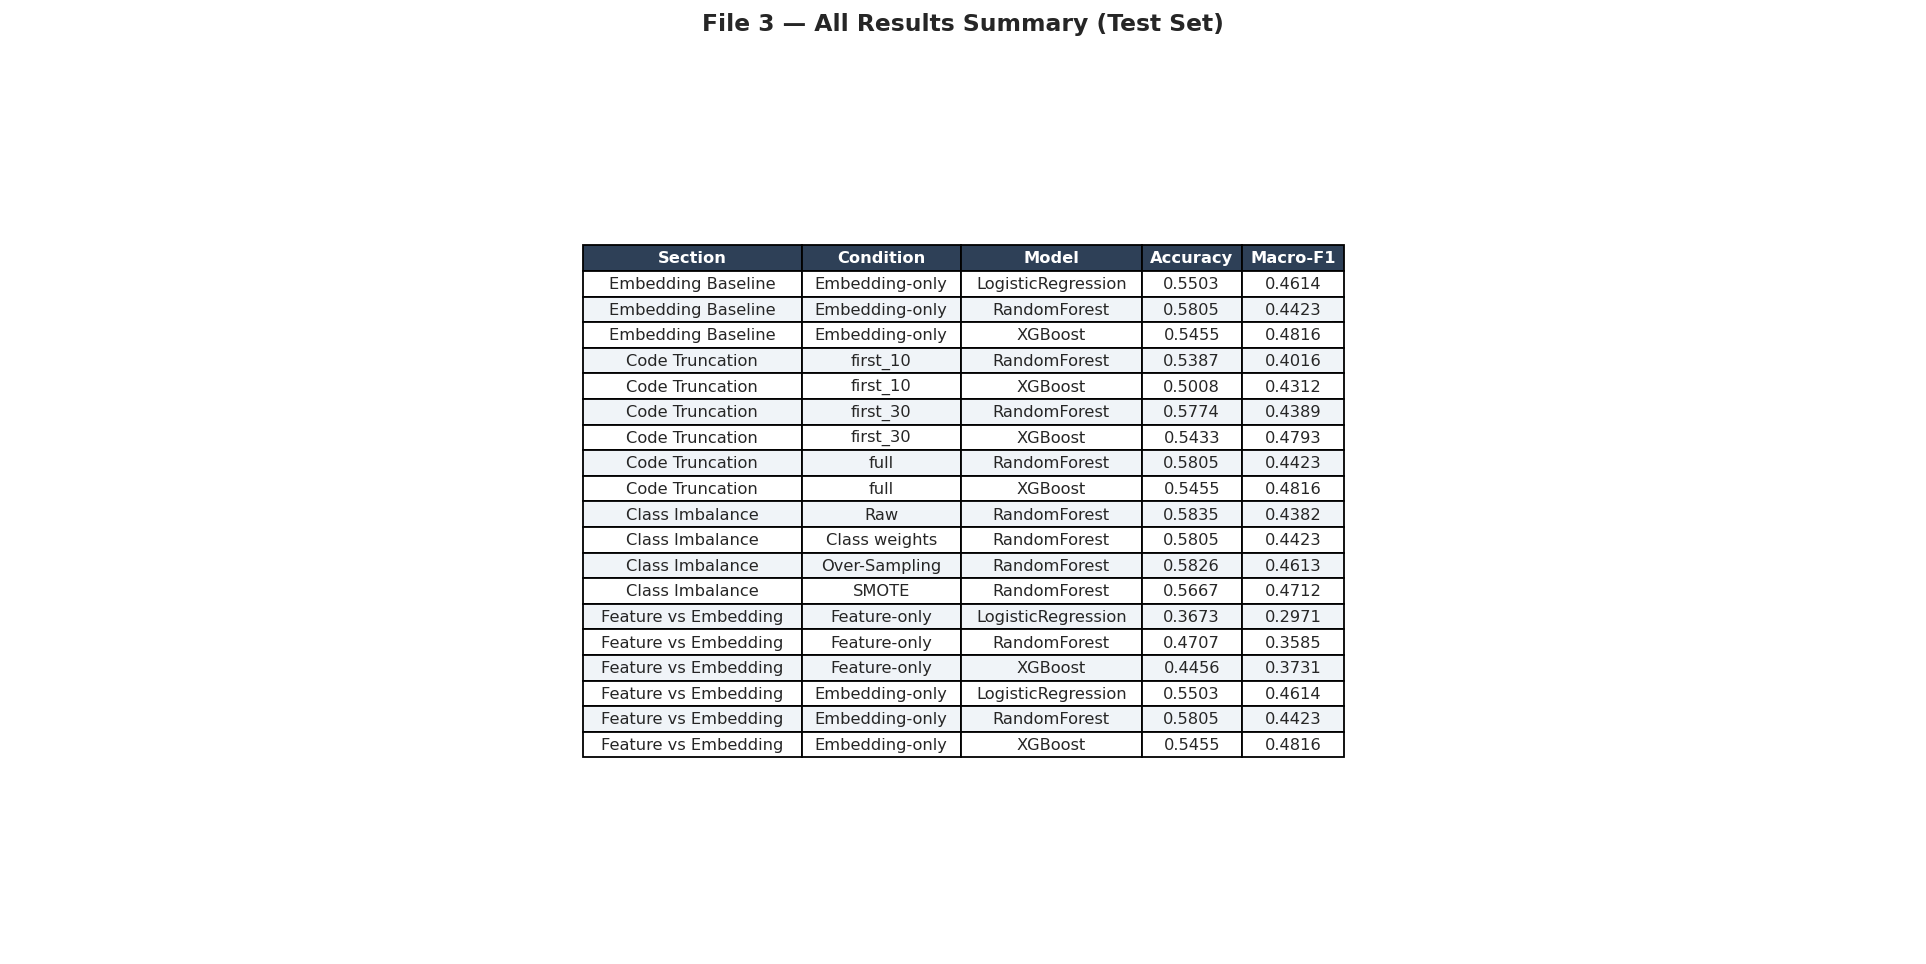


All figures saved to : /content/figures/
Results CSV saved to : /content/results/file3_results.csv


In [ ]:
all_rows = []

# Baseline (embedding)
for r in baseline_results:
    all_rows.append({"Section": "Embedding Baseline", "Condition": "Embedding-only",
                     "Model": r["model"], "Accuracy": r["accuracy"], "Macro-F1": r["macro_f1"]})

# Truncation
for r in trunc_results:
    for clf_name in ["RandomForest", "XGBoost"]:
        all_rows.append({"Section": "Code Truncation", "Condition": r["truncation"],
                         "Model": clf_name,
                         "Accuracy": r[f"{clf_name}_accuracy"],
                         "Macro-F1": r[f"{clf_name}_macro_f1"]})

# Imbalance
for r in imbalance_results:
    all_rows.append({"Section": "Class Imbalance", "Condition": r["strategy"],
                     "Model": "RandomForest",
                     "Accuracy": r["accuracy"], "Macro-F1": r["macro_f1"]})

# Comparison
for r in all_comparison:
    all_rows.append({"Section": "Feature vs Embedding", "Condition": r["condition"],
                     "Model": r["model"], "Accuracy": r["accuracy"], "Macro-F1": r["macro_f1"]})

summary = pd.DataFrame(all_rows)
csv_path = os.path.join(RSLTS, "file3_results.csv")
summary.to_csv(csv_path, index=False)
print(f"Results saved to: {csv_path}")

# Summary figure
fig, ax = plt.subplots(figsize=(15, max(6, len(summary)*0.4)))
ax.axis("off")
tbl = ax.table(cellText=summary.values, colLabels=summary.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width(range(len(summary.columns)))
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2E4057")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#F0F4F8")
ax.set_title("File 3 — All Results Summary (Test Set)",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, "final_summary_table.png")); plt.show()

print(f"\nAll figures saved to : {FIGS}/")
print(f"Results CSV saved to : {csv_path}")
